In [1]:
import numpy as np
import pandas as pd

In [2]:
# ดึงไฟล์ clean ai_job_dataset data เข้ามา
df = pd.read_csv("/content/drive/MyDrive/project stat com/ai_job_dataset.csv")

In [3]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [4]:
# ตรวจหาค่า missing
df.isnull().sum()

,0
job_id,0
job_title,0
salary_usd,0
salary_currency,0
experience_level,0
employment_type,0
company_location,0
company_size,0
employee_residence,0
remote_ratio,0


In [5]:
# เรียกดูเฉพาะค่า United States
df_united_states = df[df['company_location'] == 'United States']
display(df_united_states.head())

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
21,AI00022,Autonomous Systems Engineer,102550,USD,MI,PT,United States,M,United States,0,"Tableau, Spark, NLP, TensorFlow, PyTorch",Bachelor,2,Automotive,2024-04-23,2024-06-23,625,10.0,Cognitive Computing
40,AI00041,Data Scientist,96956,USD,MI,FT,United States,M,China,0,"Data Visualization, Azure, Spark, MLOps",Bachelor,2,Telecommunications,2024-02-24,2024-03-09,761,5.3,DataVision Ltd
41,AI00042,AI Architect,196954,USD,SE,FL,United States,L,United States,50,"Java, Mathematics, SQL",Bachelor,8,Finance,2025-03-17,2025-04-16,2290,7.5,DataVision Ltd
45,AI00046,AI Research Scientist,174663,USD,SE,CT,United States,M,Singapore,50,"Data Visualization, Statistics, R",Associate,7,Media,2024-01-10,2024-03-22,1151,5.4,DeepTech Ventures
52,AI00053,Research Scientist,106579,USD,MI,PT,United States,S,United States,100,"Docker, Tableau, Mathematics",Associate,3,Gaming,2024-02-24,2024-05-02,2028,5.4,Cognitive Computing


In [6]:
df_united_states.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,724.000000,724.000000,724.000000,724.000000,724.000000
mean,146833.045580,48.895028,6.367403,1493.426796,7.568508
std,66654.990254,41.648533,5.549260,571.540994,1.469855
min,54512.000000,0.000000,0.000000,500.000000,5.000000
25%,93625.750000,0.000000,2.000000,998.000000,6.275000
50%,128606.000000,50.000000,5.000000,1493.500000,7.700000
75%,187721.500000,100.000000,10.000000,2002.250000,8.900000
max,344471.000000,100.000000,19.000000,2493.000000,10.000000


In [7]:
# หา IQR
Q1 = df_united_states['salary_usd'].quantile(0.25)
Q3 = df_united_states['salary_usd'].quantile(0.75)
IQR = Q3 - Q1

# หา Outlier ที่อยู่เหนือขอบเขตบน
outliers_upper = df_united_states[df_united_states['salary_usd'] > Q3 + 1.5*IQR]

# หา Outlier ที่อยู่ต่ำกว่าขอบเขตล่าง
outliers_lower = df_united_states[df_united_states['salary_usd'] < Q1 - 1.5*IQR]

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Interquartile Range) for salary_usd: {IQR}")
print("\nOutliers (Upper Bound):")
display(outliers_upper)
print("\nOutliers (Lower Bound):")
display(outliers_lower)

Q1 (25th percentile): 93625.75
Q3 (75th percentile): 187721.5
IQR (Interquartile Range) for salary_usd: 94095.75

Outliers (Upper Bound):


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
2560,AI02561,Head of AI,342272,USD,EX,PT,United States,L,Austria,50,"Hadoop, Azure, NLP, Mathematics, GCP",Bachelor,18,Real Estate,2024-05-14,2024-05-31,1979,5.7,Neural Networks Co
3304,AI03305,Deep Learning Engineer,338443,USD,EX,FL,United States,L,Norway,0,"NLP, Scala, Computer Vision, Python",Associate,11,Finance,2024-02-29,2024-04-26,1778,5.6,Digital Transformation LLC
3370,AI03371,Robotics Engineer,334881,USD,EX,FL,United States,L,United States,0,"TensorFlow, R, Mathematics",Associate,13,Government,2025-03-31,2025-06-12,1486,9.7,Predictive Systems
3581,AI03582,Research Scientist,333499,USD,EX,FL,United States,L,United States,50,"NLP, Docker, SQL, AWS, PyTorch",Master,19,Retail,2025-03-02,2025-03-26,1347,8.8,Future Systems
3885,AI03886,Robotics Engineer,337306,USD,EX,FT,United States,L,United States,0,"Git, Tableau, PyTorch, SQL",PhD,19,Telecommunications,2024-04-16,2024-05-31,2063,7.9,AI Innovations
4304,AI04305,Data Analyst,336904,USD,EX,CT,United States,L,United States,0,"Python, TensorFlow, Data Visualization, PyTorch",Master,16,Automotive,2024-03-02,2024-04-27,2075,8.3,Predictive Systems
5632,AI05633,AI Specialist,341883,USD,EX,PT,United States,L,Germany,0,"Computer Vision, Python, Mathematics",Bachelor,10,Automotive,2024-04-14,2024-05-16,1436,8.8,Cognitive Computing
6494,AI06495,Machine Learning Engineer,344427,USD,EX,PT,United States,L,Austria,100,"Linux, MLOps, Spark, SQL, Kubernetes",PhD,17,Manufacturing,2024-12-13,2025-02-22,2202,8.0,Digital Transformation LLC
8141,AI08142,Head of AI,333453,USD,EX,FL,United States,L,South Korea,100,"Spark, GCP, SQL, R, Data Visualization",Master,16,Retail,2024-01-23,2024-04-04,1336,6.5,Machine Intelligence Group
9067,AI09068,Head of AI,343803,USD,EX,FL,United States,L,United States,50,"Docker, Kubernetes, Git",Master,19,Government,2024-07-07,2024-09-16,636,9.5,Algorithmic Solutions



Outliers (Lower Bound):


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name


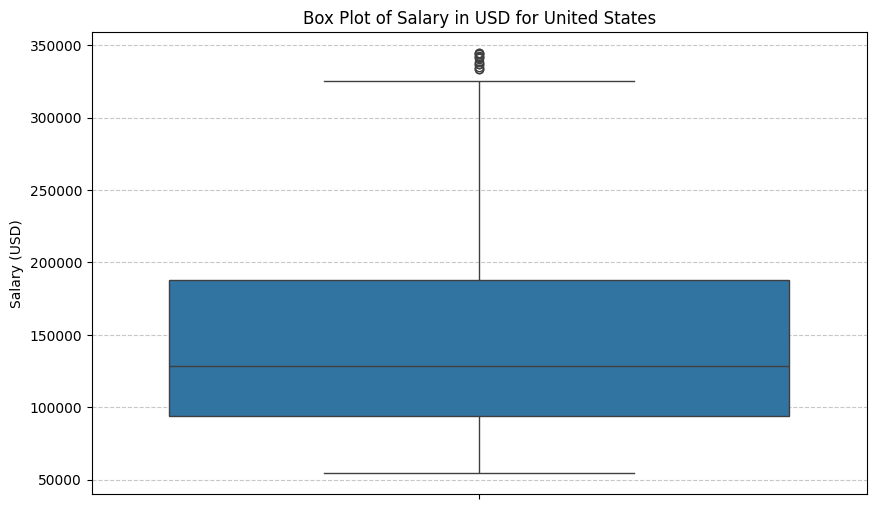

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(y=df_united_states['salary_usd'])
plt.title('Box Plot of Salary in USD for United States')
plt.ylabel('Salary (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

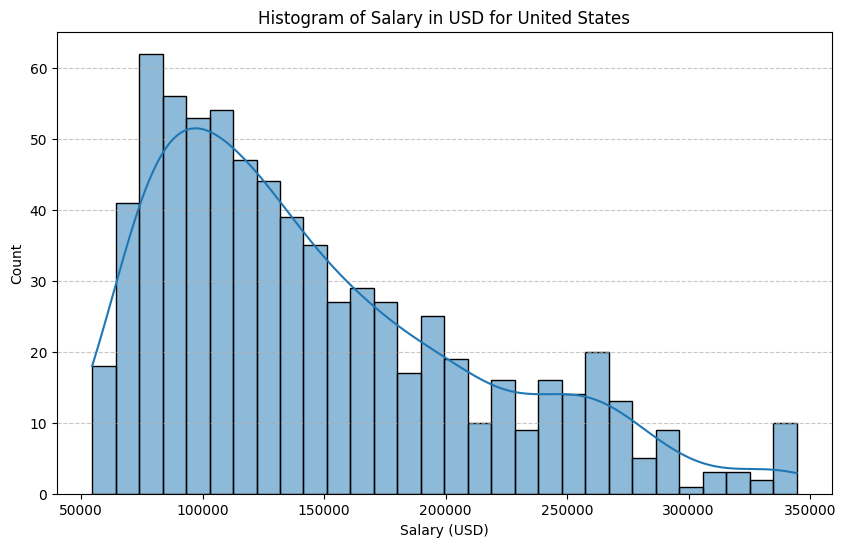

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_united_states['salary_usd'], bins=30, kde=True)
plt.title('Histogram of Salary in USD for United States')
plt.xlabel('Salary (USD)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [10]:
import statsmodels.api as sm

df = df[df["company_location"] == "United States"]

# สร้างตัวแปร  y และ x โดยใช้ df_united_states ซึ่งเป็นข้อมูลที่มีอยู่แล้ว
y = df_united_states["salary_usd"]
X = df_united_states[[
    "job_title",
    "experience_level",
    "company_size",
    "employment_type"
]]

# แปลงตัวแปรประเภทข้อความให้เป็นตัวเลข 0 และ 1 โดยใช้ dummy
X = pd.get_dummies(X, drop_first=True)

# แปลงค่าทั้งหมดใน X ให้เป็น integer
X = X.astype(int)
X = sm.add_constant(X)

# สร้างแบบจำลองด้วยวิธีกำลังสองน้อยที่สุด
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             salary_usd   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     162.0
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          5.00e-279
Time:                        09:06:12   Log-Likelihood:                -8349.6
No. Observations:                 724   AIC:                         1.676e+04
Df Residuals:                     696   BIC:                         1.688e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [11]:
# เลือกใช้ตัวแปรต้น (x) บางตัว ในการพิจารณา โดยจะให้เป็น X2
X2 = df_united_states[[
    "experience_level",
    "company_size"
]]

X2 = pd.get_dummies(X2, drop_first=True)

X2 = X2.astype(int)
X2 = sm.add_constant(X2)

model2 = sm.OLS(y, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             salary_usd   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     879.5
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          2.93e-303
Time:                        09:06:12   Log-Likelihood:                -8357.7
No. Observations:                 724   AIC:                         1.673e+04
Df Residuals:                     718   BIC:                         1.675e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                9.736e+04   2

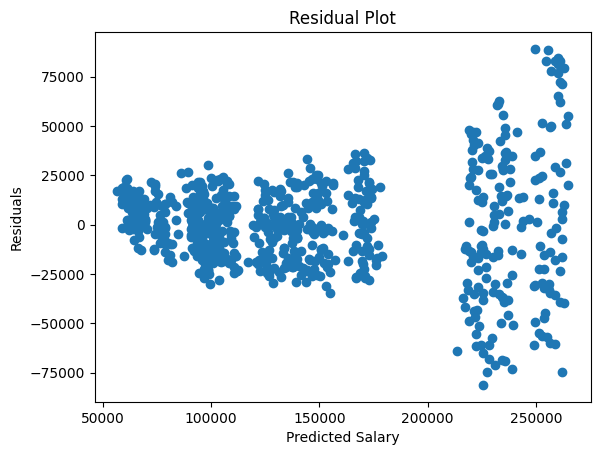

In [12]:
import matplotlib.pyplot as plt

residuals = model.resid

# ทำนายเงินเดือนซึ่งคือค่า y โดยใช้ x
predicted_salary = model.predict(X)

plt.scatter(predicted_salary, residuals)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [13]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             salary_usd   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     162.0
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          5.00e-279
Time:                        09:06:13   Log-Likelihood:                -8349.6
No. Observations:                 724   AIC:                         1.676e+04
Df Residuals:                     696   BIC:                         1.688e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                  9.359e+04   4917.791     19.031      0.000    8.39e+04    1.03e+05
job_title_AI Consultant                7171.3228   5994.282      1.196      0.232   -4597.720    1.89e+04
job_title_AI Product Manager           3400.2319   5795.699      0.587      0.558   -7978.918    1.48e+04
job_title_AI Research Scientist        3620.4699   5624.222      0.644      0.520   -7422.005    1.47e+04
job_title_AI Software Engineer         2937.0006   5923.558      0.496      0.620   -8693.184    1.46e+04
job_title_AI Specialist                4990.9713   5549.598      0.899      0.369   -5904.990    1.59e+04
job_title_Autonomous Systems Engineer  6185.8117   5631.135      1.099      0.272   -4870.236    1.72e+04
job_title_Computer Vision Engineer     1.107e+04   6484.795      1.706      0.088   -1666.726    2.38e+04
job_title_Data Analyst                 7249.8604   5567.953      1.302      0.193   -3682.137    1.82e+04
job_title_Data Engineer                4937.4561   5790.528      0.853      0.394   -6431.541    1.63e+04
job_title_Data Scientist               7258.1468   5535.973      1.311      0.190   -3611.061    1.81e+04
job_title_Deep Learning Engineer      -2337.0399   5906.400     -0.396      0.692   -1.39e+04    9259.458
job_title_Head of AI                   9220.2524   5703.771      1.617      0.106   -1978.408    2.04e+04
job_title_ML Ops Engineer              2039.5120   6085.184      0.335      0.738   -9908.007     1.4e+04
job_title_Machine Learning Engineer    1993.3185   6086.002      0.328      0.743   -9955.805    1.39e+04
job_title_Machine Learning Researcher   510.8640   6008.418      0.085      0.932   -1.13e+04    1.23e+04
job_title_NLP Engineer                 2040.1694   5823.018      0.350      0.726   -9392.618    1.35e+04
job_title_Principal Data Scientist     4335.6611   5559.572      0.780      0.436   -6579.881    1.53e+04
job_title_Research Scientist           1.026e+04   5816.545      1.764      0.078   -1157.569    2.17e+04
job_title_Robotics Engineer            5195.5456   5635.792      0.922      0.357   -5869.646    1.63e+04
experience_level_EX                    1.592e+05   2711.038     58.720      0.000    1.54e+05    1.65e+05
experience_level_MI                    2.951e+04   2694.368     10.952      0.000    2.42e+04    3.48e+04
experience_level_SE                     7.32e+04   2719.972     26.913      0.000    6.79e+04    7.85e+04
company_size_M                        -2.092e+04   2297.855     -9.106      0.000   -2.54e+04   -1.64e+04
company_size_S                         -3.33e+04   2337.178    -14.247      0.000   -3.79e+04   -2.87e+04
employment_type_FL                    -1103.6429   2602.922     -0.424      0.672   -6214.162    4006.877
employmen

In [14]:
# เชื่อมต่อ Google Colab กับ Google Drive แล้วบันทึกข้อมูลที่ประมวลผลแล้วออกมาเป็นไฟล์ CSV
from google.colab import drive
drive.mount('/content/drive')


output_path = '/content/drive/MyDrive/project stat com/AI Job Market & Salary Trends Clean.csv'
df.to_csv(output_path, index=False)
print(f'AI Job Market & Salary Trends Clean {output_path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AI Job Market & Salary Trends Clean /content/drive/MyDrive/project stat com/AI Job Market & Salary Trends Clean.csv


In [15]:
import pandas as pd

# เปรียบเทียบเงินเดือนจริงกับค่าทำนายเงินเดือน
result = pd.DataFrame({
    'y_true': y,
    'y_pred': predicted_salary
})

result.to_csv('prediction_results.csv', index=False)

In [16]:
# คำนวณค่าความผิดพลาด
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# เปรียบเทียบค่าเงินเดือนจริงกับค่าทำนาย
rmse = np.sqrt(mean_squared_error(y, predicted_salary))

# ค่าเฉลี่ยของความแตกต่างระหว่างค่าเงินเดือนจริงกับค่าทำนาย
mae = mean_absolute_error(y, predicted_salary)

# วัดค่าความคลาดเคลื่อนในการทำนายในรูปแบบเปอร์เซ็นต์
mape = np.mean(np.abs((y - predicted_salary) / y)) * 100

metrics = pd.DataFrame({
    'Metric': ['RMSE','MAE','MAPE'],
    'Value': [rmse, mae, mape]
})

metrics.to_csv('model_metrics.csv', index=False)

In [17]:
display(metrics)

,Metric,Value
0,RMSE,24677.042271
1,MAE,18207.628028
2,MAPE,12.343532


In [18]:
# ตารางเก็บค่าสัมประสิทธิ์ของตัวแปร
coef = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.params
})

# บันทึกเป็นไฟล์ csv
coef.to_csv('coefficients.csv', index=False)

In [19]:
result.to_csv('prediction_results.csv', index=False)

In [20]:
metrics.to_csv('model_metrics.csv', index=False)

In [21]:
coef.to_csv('coefficients.csv', index=False)

In [22]:
!ls

coefficients.csv  drive  model_metrics.csv  prediction_results.csv  sample_data
